#

# Final Assigment

Paul Sandegård - BI 24



## Importing Libaries

In [34]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

## Question 1

In [28]:
# Create Dateframe
df = pd.DataFrame({
    'Car_No': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'EngineSize': [2.0, 1.4, 3.5, 1.8, 2.5, 1.6, 2.2, 3.0, 1.5, 2.8],
    'Mileage': [50, 120, 30, 90, 65, 150, 40, 75, 110, 55],
    'Price': [18, 8.5, 35, 12.5, 16, 6, 20, 25, 9.5, 22],
    'Sold_in_7_Days': ['Y', 'N', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y']  
})
df['QuickSale'] = df['Sold_in_7_Days'].map({'Y': 1, 'N': 0})

print(df)
print(df['QuickSale'])

   Car_No  EngineSize  Mileage  Price Sold_in_7_Days  QuickSale
0       1         2.0       50   18.0              Y          1
1       2         1.4      120    8.5              N          0
2       3         3.5       30   35.0              Y          1
3       4         1.8       90   12.5              Y          1
4       5         2.5       65   16.0              N          0
5       6         1.6      150    6.0              N          0
6       7         2.2       40   20.0              Y          1
7       8         3.0       75   25.0              N          0
8       9         1.5      110    9.5              Y          1
9      10         2.8       55   22.0              Y          1
0    1
1    0
2    1
3    1
4    0
5    0
6    1
7    0
8    1
9    1
Name: QuickSale, dtype: int64


### 1A

In [18]:
# Train linear regression model
X = df[['EngineSize', 'Mileage']].values  
y = df['Price'].values                    
model = LinearRegression()
model.fit(X, y)

engine_range = np.linspace(df['EngineSize'].min(), df['EngineSize'].max(), 10)
mileage_range = np.linspace(df['Mileage'].min(), df['Mileage'].max(), 10)
engine_grid, mileage_grid = np.meshgrid(engine_range, mileage_range)
X_grid = np.column_stack([engine_grid.ravel(), mileage_grid.ravel()])
price_pred = model.predict(X_grid)
price_grid = price_pred.reshape(engine_grid.shape)

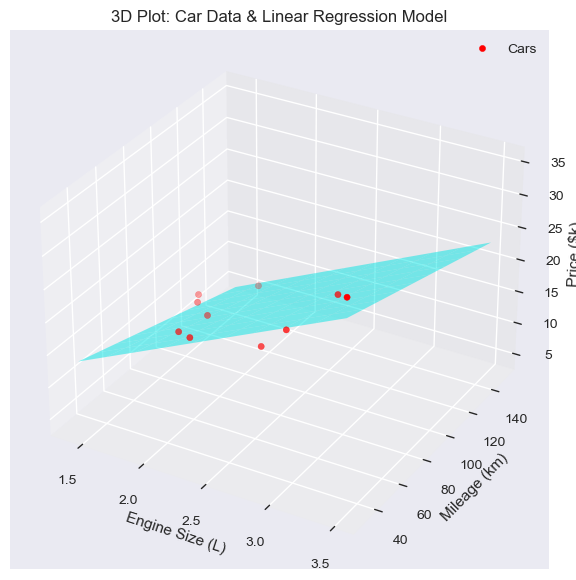

In [19]:
# Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot 
ax.scatter(df['EngineSize'], df['Mileage'], df['Price'], c='r', marker='o', label='Cars')

# Regressionplanet
ax.plot_surface(engine_grid, mileage_grid, price_grid, alpha=0.5, color='cyan')

ax.set_xlabel('Engine Size (L)')
ax.set_ylabel('Mileage (km)')
ax.set_zlabel('Price ($k)')
ax.set_title('3D Plot: Car Data & Linear Regression Model')
ax.legend()

plt.show()

Reference: Lesson 3 - Lesson3_MR-3Dplot.ipynb

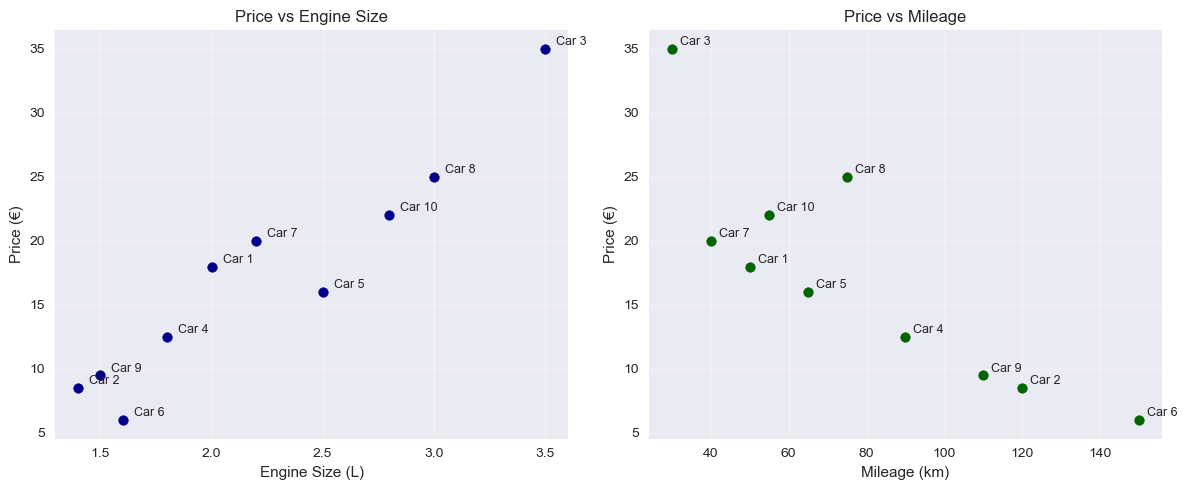

In [20]:
plt.figure(figsize=(12, 5))

# Graph 1: Price vs Engine Size
plt.subplot(1, 2, 1)
plt.scatter(df['EngineSize'], df['Price'], color='darkblue')
for i, row in df.iterrows():
    plt.text(row['EngineSize'] + 0.05, row['Price'] + 0.3,
             f"Car {int(row['Car_No'])}", fontsize=9)
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (€)')
plt.title('Price vs Engine Size')
plt.grid(True, alpha=0.3)

# Graph 2: Price vs Mileage
plt.subplot(1, 2, 2)
plt.scatter(df['Mileage'], df['Price'], color='darkgreen')
for i, row in df.iterrows():
    plt.text(row['Mileage'] + 2, row['Price'] + 0.3,
             f"Car {int(row['Car_No'])}", fontsize=9)
plt.xlabel('Mileage (km)')
plt.ylabel('Price (€)')
plt.title('Price vs Mileage')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2D-graphs to make the prior(3d graph) more understandable 

### 1B

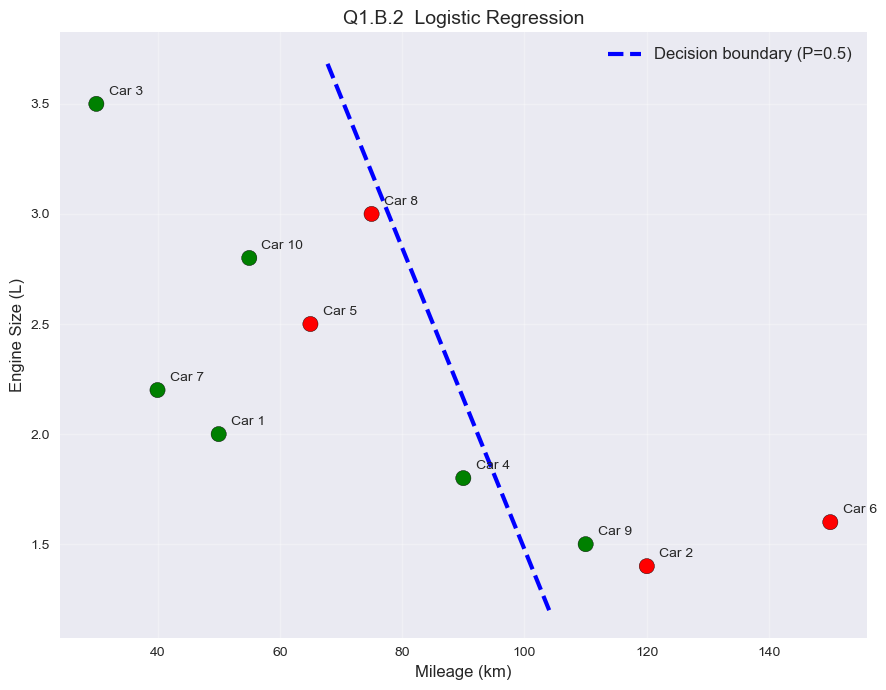

In [21]:
# Logistic Regression
log_model = LogisticRegression(random_state=42)
log_model.fit(df[['EngineSize', 'Mileage']], df['QuickSale'])

intercept = log_model.intercept_[0]
coef_engine = log_model.coef_[0][0]
coef_mileage  = log_model.coef_[0][1]   

engine_range = np.linspace(df['EngineSize'].min() - 0.2, df['EngineSize'].max() + 0.2, 100)

mileage_boundary = -(intercept + coef_engine * engine_range) / coef_mileage
# Plotting
plt.figure(figsize=(9, 7))

colors = {'Y': 'green', 'N': 'red'}
plt.scatter(df['Mileage'], df['EngineSize'], 
            c=df['Sold_in_7_Days'].map(colors), 
            s=120, edgecolors='black')

for i, row in df.iterrows():
    plt.text(row['Mileage'] + 2, row['EngineSize'] + 0.04, 
             f"Car {int(row['Car_No'])}")

plt.plot(mileage_boundary, engine_range, 
         'b--', linewidth=3, label='Decision boundary (P=0.5)')

plt.xlabel('Mileage (km)', fontsize=12)
plt.ylabel('Engine Size (L)', fontsize=12)
plt.title('Q1.B.2  Logistic Regression', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Reference: Lession 2a-2d (touch of AI( f"Car {int(row['Car_No'])}"/colors = {'Y':'green', 'N':'red'})))

## Question 2

In [22]:
#Create Dataframe
df2 = pd.DataFrame({
    'Project_No': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Team_Size': [5, 12, 7, 15, 6, 10, 8, 14, 5, 11],
    'QA_Coverage': [95, 70, 85, 60, 90, 75, 80, 50, 98, 65],
    'Schedule_Days': [100, 180, 90, 200, 110, 150, 130, 220, 80, 170],
    'Tech_Stack': ['New', 'Old', 'New', 'Old', 'New', 'Old', 'New', 'Old', 'New', 'Old'],
    'Success': ['Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'N'] 
})

df2['Success_Binary'] = df2['Success'].map({'Y': 1, 'N': 0})        
df2['Tech_Stack_Binary'] = df2['Tech_Stack'].map({'New': 1, 'Old': 0})  

print(df2)

   Project_No  Team_Size  QA_Coverage  Schedule_Days Tech_Stack Success  \
0           1          5           95            100        New       Y   
1           2         12           70            180        Old       N   
2           3          7           85             90        New       Y   
3           4         15           60            200        Old       N   
4           5          6           90            110        New       Y   
5           6         10           75            150        Old       Y   
6           7          8           80            130        New       Y   
7           8         14           50            220        Old       N   
8           9          5           98             80        New       Y   
9          10         11           65            170        Old       N   

   Success_Binary  Tech_Stack_Binary  
0               1                  1  
1               0                  0  
2               1                  1  
3               0 

In [23]:
# Prepare data for modeling
X = df2[['Team_Size', 'QA_Coverage', 'Schedule_Days', 'Tech_Stack_Binary']]
y = df2['Success_Binary']

X_cat = df2[['Team_Size', 'QA_Coverage', 'Schedule_Days', 'Tech_Stack']]
X_encoded = pd.get_dummies(X_cat, drop_first=True)   

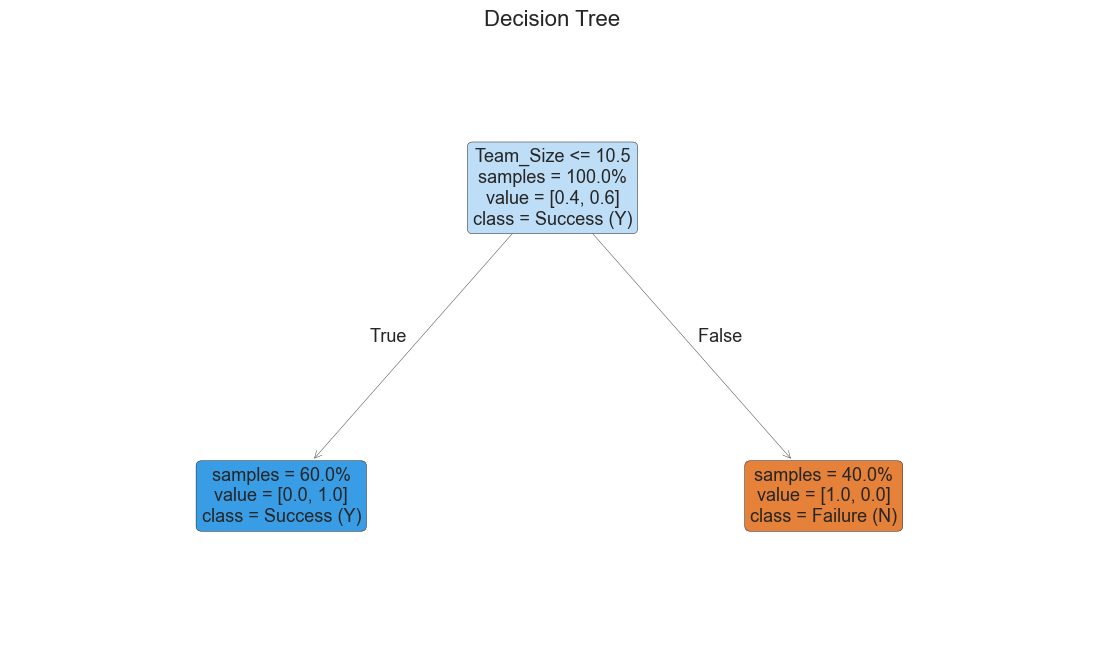

In [24]:
# Decision Tree 
tree = DecisionTreeClassifier(random_state=42, max_depth=None, min_samples_leaf=2)
tree.fit(X, y)

plt.figure(figsize=(14, 8))
plot_tree(tree, 
          feature_names=['Team_Size', 'QA_Coverage', 'Schedule_Days', 'Tech_Stack'],
          class_names=['Failure (N)', 'Success (Y)'],
          filled=True, rounded=True, fontsize=13, proportion=True, impurity=False)
plt.title("Decision Tree", fontsize=16)
plt.show()

Reference: Lesson 4 and Lesson4a.ipynb. This one shows the optimal nodes(Entophy)

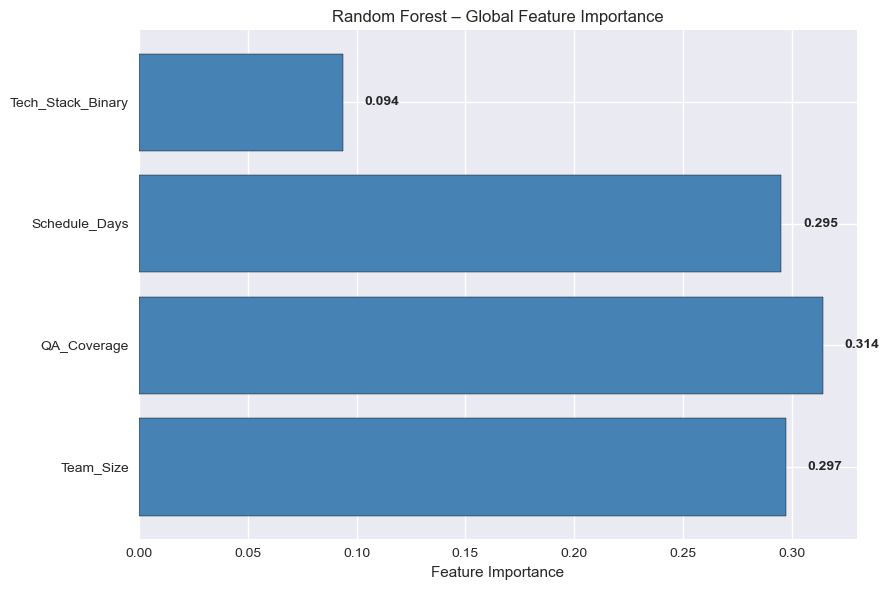

In [25]:
# Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
feat_names = X.columns

plt.figure(figsize=(9,6))
bars = plt.barh(feat_names, importances, color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title('Random Forest – Global Feature Importance')

for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{importances[i]:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Reference: Lesson 4 and Lesson4b.ipynb 

## Question 3

## Question 4


### Load the Wine Dataset

In [ ]:
#load dataset
data = load_wine()

X = data.data
feature_names = data.feature_names

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {feature_names}")

Number of samples: 178
Number of features: 13
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [35]:
# standerdize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

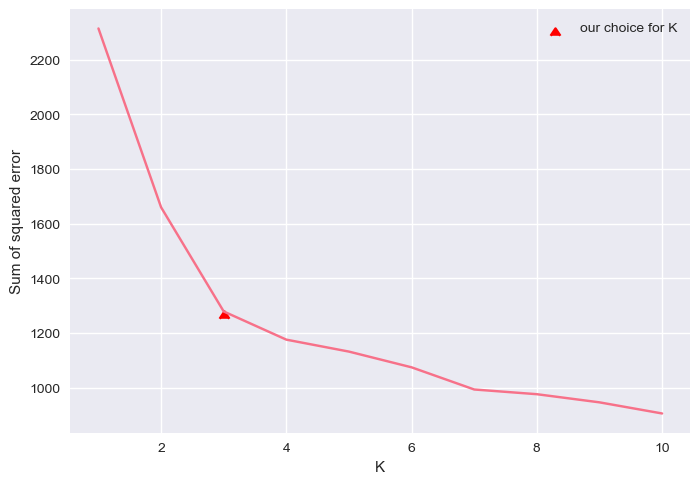

In [39]:
# Elbow Method
sse = []
k_rng = range(1, 11)
for k in k_rng:
    km = KMeans(n_clusters=k, random_state=7)
    km.fit(X_scaled)
    sse.append(km.inertia_)
 
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)
plt.scatter(k_rng[2], sse[2], color='red', marker=6, label='our choice for K')
plt.legend()
plt.show()

Reference: Kmeans_clustering.ipynb

In [37]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

K=2, Silhouette Score=0.4750
K=3, Silhouette Score=0.5602
K=4, Silhouette Score=0.4914
K=5, Silhouette Score=0.4499
K=6, Silhouette Score=0.4122
K=7, Silhouette Score=0.4034
K=8, Silhouette Score=0.4174
K=9, Silhouette Score=0.4215
K=10, Silhouette Score=0.4060


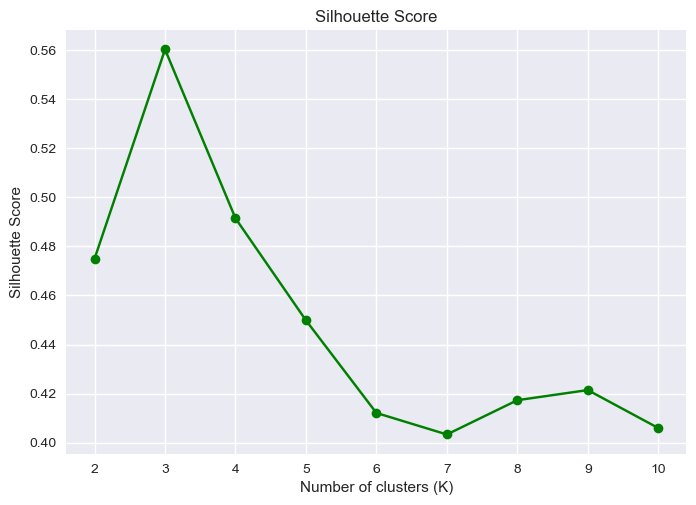

In [38]:
silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.plot(K_range_sil, silhouette_scores, 'go-')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

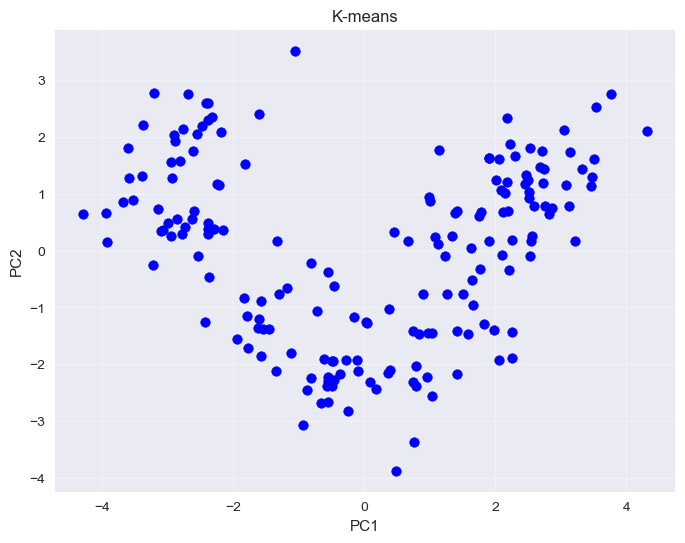

In [ ]:
# K-means without chosen centroids
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue',label='Data points')
plt.title('K-means')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

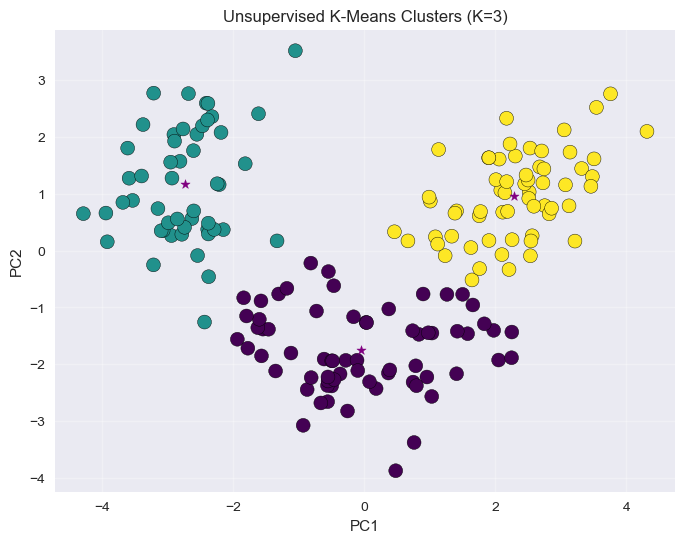

In [ ]:
# K-means with chosen centroids(K=3)
kmeans_best = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_best.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=100, edgecolors='k')
plt.title('Unsupervised K-Means Clusters (K=3)')
plt.scatter(kmeans_best.cluster_centers_[:, 0], kmeans_best.cluster_centers_[:, 1], color='purple', marker='*', label='centroid')
plt.xlabel('PC1')
plt.ylabel('PC2' )
plt.grid(True, alpha=0.3)
plt.show()

Reference: Lesson 6, and Kmeans_clustering.Ipynb

## Part B: Supervised Classification

In [ ]:
# Target and train/test split
y = data.target
target_names = data.target_names  

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 142, Test samples: 36


In [ ]:
# Model 1: Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
# Model 2: Logistic Regression
logreg = LogisticRegression(C=1.0, max_iter=500,random_state=42)           
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print("Random Forest  test accuracy:", accuracy_score(y_test, rf_pred))
print("Logistic Regression test accuracy:", accuracy_score(y_test, logreg_pred))

Random Forest  test accuracy: 1.0
Logistic Regression test accuracy: 0.9722222222222222


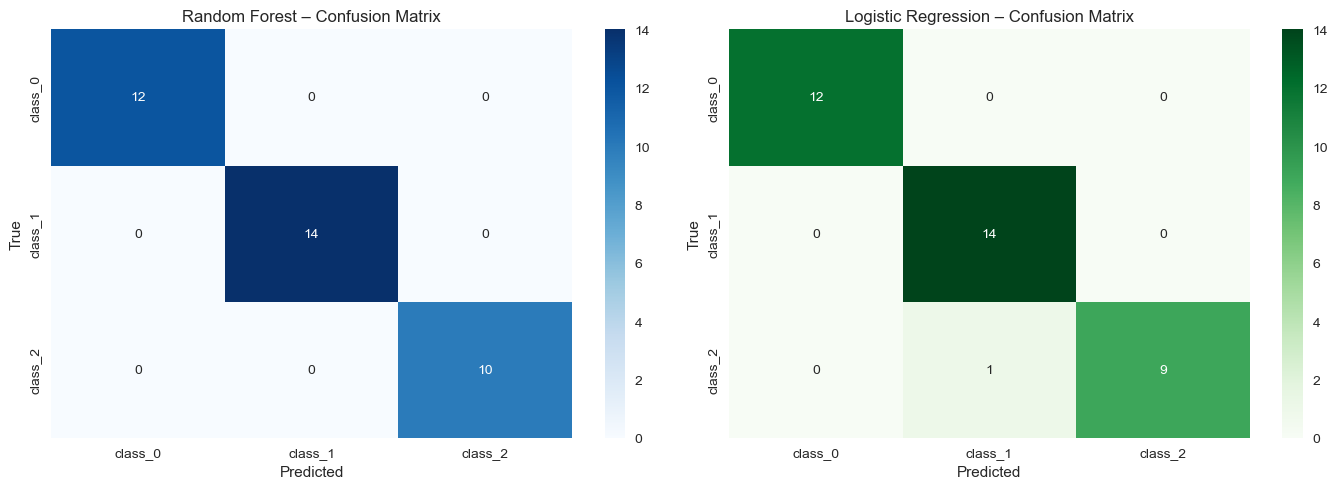

In [ ]:
# Matrixes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title('Random Forest – Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(confusion_matrix(y_test, logreg_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Logistic Regression – Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## Part C: Tri-View Reality Check

In [ ]:
#
rf_full = RandomForestClassifier(n_estimators=500, random_state=42)
rf_full.fit(X_scaled, y)                          
rf_predictions_full = rf_full.predict(X_scaled)   

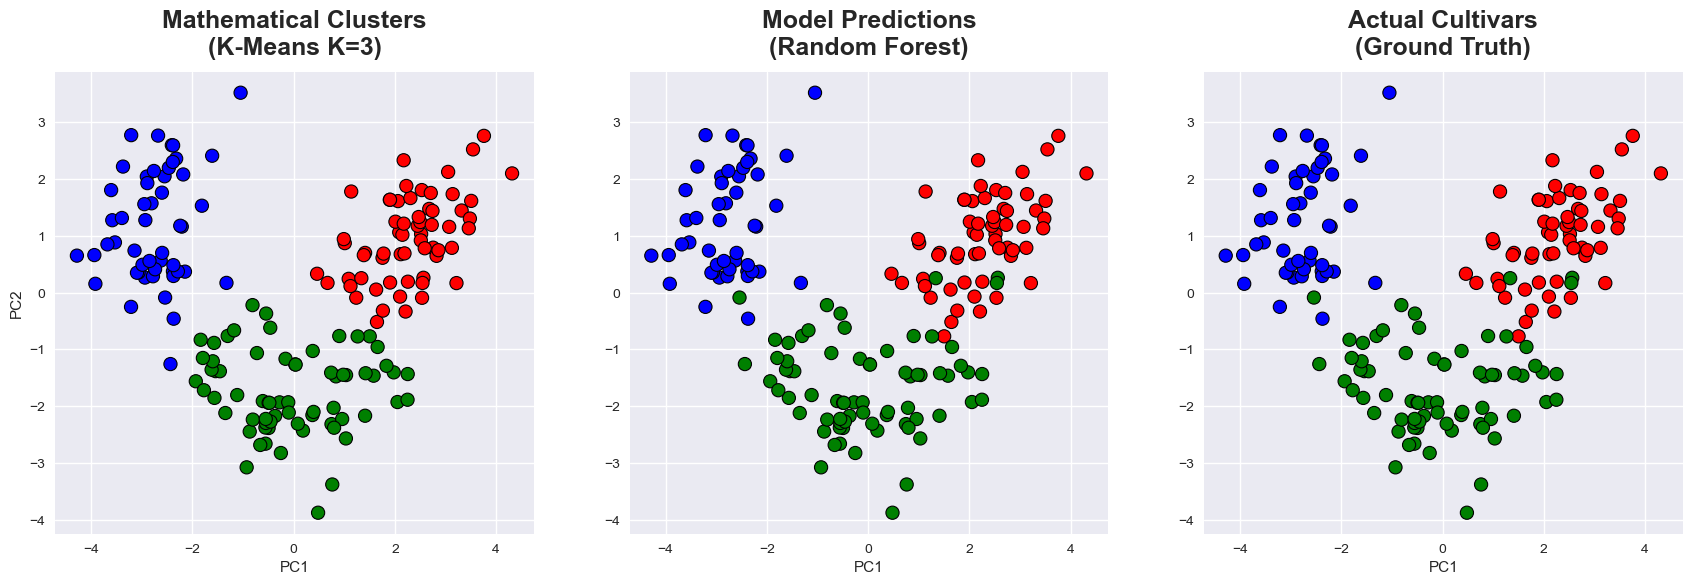

In [ ]:
import matplotlib.colors as mcolors

colors = ['green','blue', 'red']
cmap_fixed= mcolors.ListedColormap(colors)
colors2 = ['red','green','blue']
cmap_fixed2 = mcolors.ListedColormap(colors2)


fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                c=cluster_labels, cmap=cmap_fixed, s=90, edgecolors='k', linewidth=0.8)
axes[0].set_title('Mathematical Clusters\n(K-Means K=3)',fontsize=18, fontweight='bold', y=1.02)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                c=rf_predictions_full, cmap=cmap_fixed2, s=90, edgecolors='k', linewidth=0.8)
axes[1].set_title('Model Predictions\n(Random Forest)', fontsize=18, fontweight='bold', y=1.02)
axes[1].set_xlabel('PC1')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], 
                c=y, cmap=cmap_fixed2, s=90, edgecolors='k', linewidth=0.8)
axes[2].set_title('Actual Cultivars\n(Ground Truth)', fontsize=18, fontweight='bold', y=1.02)
axes[2].set_xlabel('PC1')

#plt.tight_layout()
plt.show()

Reference: Kmeans_cluster.ipynb, Used some AI for some help to design it so it is watchable in word, also took the fast solution too the colors of the clusters (where without the 

- "colors = ['green','blue', 'red']
- cmap_fixed= mcolors.ListedColormap(colors)
- colors2 = ['red','green','blue']
- cmap_fixed2 = mcolors.ListedColormap(colors2)"

showed the color in the first graph with clusters diffrent colours I could use the excempel from Kmeans_cluster.ipynb, but i learnt afterwards that the colour shouldnt be diffrent
 ).